# Batch-Aware Spatial Multi-Omics Integration on Simulated Batch-Effect Data

This notebook replaces the real A1/D1 tissue pipeline with a **controlled synthetic experiment** designed to answer one question:

> **Does the MMD batch-alignment term in the model actually reduce batch effects while preserving biological structure?**

The experiment creates:
- multiple simulated spatial samples,
- two modalities per spot (RNA-like and protein-like),
- known biological domains,
- injected batch effects that shift the same biology across samples.

Then it trains the same model twice:

1. **No batch correction**
2. **MMD batch correction**

Because the ground truth is known, we can test whether MMD:
- improves **batch mixing**,
- reduces **sample separation**,
- and still preserves **true biological clusters**.

## 1. Imports and configuration
This section imports the model, defines reproducibility settings, and creates output folders.

In [1]:
import os
import sys
import random

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from scipy.stats import entropy

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

OUT_DIR = "outputs/simulated_batch_mmd"
FIG_DIR = os.path.join(OUT_DIR, "figures")
TABLE_DIR = os.path.join(OUT_DIR, "tables")
MODEL_DIR = os.path.join(OUT_DIR, "models")

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

DEVICE = "cpu"

# Simulation settings
NUM_SAMPLES = 3
GRID_H = 18
GRID_W = 18
N_SPOTS_PER_SAMPLE = GRID_H * GRID_W
N_CLUSTERS = 4

# Model settings
IN_DIM = 30
HIDDEN_DIM = 64
LATENT_DIM = 16
SPATIAL_K = 6
FEATURE_K = 10

# Training settings
# Fix 1: 800 epochs — original was still converging at 400
EPOCHS = 800
LR = 1e-3
LAMBDA_CORR = 1.0
# Fix 2: stronger batch penalty and warmup schedule
LAMBDA_BATCH = 1.0           # was 0.5 — raised to match corr loss scale
LAMBDA_BATCH_WARMUP = 200    # NEW: ramp lambda_batch from 0 over first 200 epochs
                             #      so the encoder learns biology before being pushed to mix
# Fix 3: use multi-scale MMD kernel instead of fixed sigma=1.0
USE_MULTISCALE_MMD = True

# ---------------------------------------------------------------------------
# Import from SpatialGlueBatchAware
# ---------------------------------------------------------------------------
_nb_dir = os.path.dirname(os.path.abspath(__file__)) if "__file__" in dir() else os.getcwd()
_search_paths = [_nb_dir, os.getcwd()]

_imported = False
for _p in _search_paths:
    if _p not in sys.path:
        sys.path.insert(0, _p)
    try:
        from SpatialGlueBatchAware import (
            SpatialGlueMini, total_loss,
            reconstruction_loss, correspondence_loss, gaussian_kernel,
        )
        print(f"Imported SpatialGlueBatchAware from: {_p}")
        _imported = True
        break
    except ImportError:
        pass

if not _imported:
    raise ImportError(
        "SpatialGlueBatchAware.py not found.\n"
        f"Searched: {_search_paths}\n"
        "Copy SpatialGlueBatchAware.py alongside this notebook and re-run."
    )

print(f"Total simulated spots: {NUM_SAMPLES * N_SPOTS_PER_SAMPLE}")


Imported SpatialGlueBatchAware from: c:\Users\imoha\OneDrive\Computational Biology SpatialGLUE\Project
Total simulated spots: 972


## 2. Helper functions
These helpers build graphs, generate synthetic spatial multi-omics data, train the model, and evaluate batch mixing and biological preservation.

In [2]:
def knn_edge_index(X, k):
    nbrs = NearestNeighbors(n_neighbors=k + 1).fit(X)
    _, indices = nbrs.kneighbors(X)
    edges = []
    for i in range(X.shape[0]):
        for j in indices[i, 1:]:
            edges.append([i, j])
    return torch.tensor(edges, dtype=torch.long).t().contiguous()

def offset_edge_index(edge_index, offset):
    return edge_index + offset

def pca_projection(X, n_components=2):
    pca = PCA(n_components=n_components, random_state=SEED)
    X2 = pca.fit_transform(X)
    return X2, pca.explained_variance_ratio_

def cluster_embedding(X, n_clusters=N_CLUSTERS, random_state=SEED):
    km = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=20)
    labels = km.fit_predict(X)
    return labels, km.cluster_centers_

def normalized_batch_entropy_score(embedding, batch_labels, k=30):
    embedding = np.asarray(embedding)
    batch_labels = np.asarray(batch_labels)
    k = min(k, len(embedding) - 1)
    nbrs = NearestNeighbors(n_neighbors=k + 1).fit(embedding)
    indices = nbrs.kneighbors(embedding, return_distance=False)[:, 1:]
    unique_batches = np.unique(batch_labels)
    max_entropy = np.log2(len(unique_batches)) if len(unique_batches) > 1 else 1.0
    entropies = []
    for neigh_idx in indices:
        neigh_batches = batch_labels[neigh_idx]
        counts = np.array([(neigh_batches == b).sum() for b in unique_batches], dtype=float)
        probs = counts / counts.sum()
        entropies.append(entropy(probs, base=2) / max_entropy if max_entropy > 0 else 0.0)
    return float(np.mean(entropies))

def evaluate_embedding(X, batch_labels, true_labels):
    X = np.asarray(X)
    batch_labels = np.asarray(batch_labels)
    true_labels = np.asarray(true_labels)
    pred_labels, _ = cluster_embedding(X, n_clusters=len(np.unique(true_labels)))
    metrics = {
        "batch_silhouette": silhouette_score(X, batch_labels),
        "biology_silhouette": silhouette_score(X, true_labels),
        "batch_entropy": normalized_batch_entropy_score(X, batch_labels, k=30),
        "ARI_vs_truth": adjusted_rand_score(true_labels, pred_labels),
        "NMI_vs_truth": normalized_mutual_info_score(true_labels, pred_labels),
    }
    return metrics, pred_labels

def make_spatial_domains(coords, h, w):
    x = coords[:, 0]
    y = coords[:, 1]
    labels = np.zeros(len(coords), dtype=int)
    labels[(x >= w / 2) & (y < h / 2)] = 1
    labels[(x < w / 2) & (y >= h / 2)] = 2
    labels[(x >= w / 2) & (y >= h / 2)] = 3
    center_x = (w - 1) / 2
    center_y = (h - 1) / 2
    radius = np.sqrt((x - center_x) ** 2 + (y - center_y) ** 2)
    ring_mask = (radius > min(h, w) * 0.18) & (radius < min(h, w) * 0.28)
    labels[ring_mask] = (labels[ring_mask] + 1) % 4
    return labels

def simulate_sample(sample_id, grid_h, grid_w, in_dim, n_clusters):
    xs, ys = np.meshgrid(np.arange(grid_w), np.arange(grid_h))
    coords = np.column_stack([xs.ravel(), ys.ravel()]).astype(float)
    coords = coords + np.random.normal(scale=0.15, size=coords.shape)
    coords[:, 0] += 0.10 * sample_id * np.sin(coords[:, 1] / 3.0)
    coords[:, 1] += 0.08 * sample_id * np.cos(coords[:, 0] / 4.0)
    true_labels = make_spatial_domains(coords, grid_h, grid_w)
    return coords, true_labels

def simulate_multimodal_batch_data(
    num_samples=NUM_SAMPLES,
    grid_h=GRID_H,
    grid_w=GRID_W,
    in_dim=IN_DIM,
    n_clusters=N_CLUSTERS,
):
    base_rna = np.random.normal(0, 1.0, size=(n_clusters, in_dim))
    base_prot = base_rna * 0.65 + np.random.normal(0, 0.60, size=(n_clusters, in_dim))

    all_coords, all_true, all_sample_ids, all_sample_names = [], [], [], []
    X_rna_list, X_prot_list = [], []

    for sample_id in range(num_samples):
        coords, true_labels = simulate_sample(sample_id, grid_h, grid_w, in_dim, n_clusters)
        n = len(coords)

        rna_shift = np.random.normal(loc=0.0, scale=2.0, size=(1, in_dim))
        prot_shift = np.random.normal(loc=0.0, scale=2.0, size=(1, in_dim))
        rna_scale = np.random.uniform(0.75, 1.35, size=(1, in_dim))
        prot_scale = np.random.uniform(0.75, 1.35, size=(1, in_dim))

        batch_vector = np.random.normal(size=(in_dim,))
        batch_vector /= (np.linalg.norm(batch_vector) + 1e-8)
        spatial_axis = (coords[:, 0] - coords[:, 0].mean()) / (coords[:, 0].std() + 1e-8)
        structured_shift = 1.0 * np.outer(spatial_axis, batch_vector)

        X_rna = base_rna[true_labels] + np.random.normal(scale=0.55, size=(n, in_dim))
        X_prot = base_prot[true_labels] + np.random.normal(scale=0.55, size=(n, in_dim))

        X_rna = X_rna * rna_scale + rna_shift + structured_shift
        X_prot = X_prot * prot_scale + prot_shift - structured_shift

        X_rna = X_rna + 0.10 * np.tanh(X_rna)
        X_prot = X_prot + 0.10 * np.sin(X_prot)

        all_coords.append(coords)
        all_true.append(true_labels)
        all_sample_ids.append(np.full(n, sample_id, dtype=int))
        all_sample_names.extend([f"sample_{sample_id}"] * n)
        X_rna_list.append(X_rna.astype(np.float32))
        X_prot_list.append(X_prot.astype(np.float32))

    return {
        "X_rna_all": np.vstack(X_rna_list).astype(np.float32),
        "X_prot_all": np.vstack(X_prot_list).astype(np.float32),
        "coords_all": np.vstack(all_coords).astype(np.float32),
        "true_labels": np.concatenate(all_true),
        "sample_ids": np.concatenate(all_sample_ids),
        "sample_names": np.array(all_sample_names),
        "X_rna_list": X_rna_list,
        "X_prot_list": X_prot_list,
        "coords_list": all_coords,
    }

def build_disconnected_spatial_graph(coords_list, k=SPATIAL_K):
    edges, offset = [], 0
    for coords in coords_list:
        e = knn_edge_index(coords, k)
        edges.append(offset_edge_index(e, offset))
        offset += coords.shape[0]
    return torch.cat(edges, dim=1)

def build_disconnected_feature_graph(X_list, k=FEATURE_K):
    edges, offset = [], 0
    for X in X_list:
        e = knn_edge_index(X, k)
        edges.append(offset_edge_index(e, offset))
        offset += X.shape[0]
    return torch.cat(edges, dim=1)

def standardize_per_sample(X_list):
    """
    FIX 1: Per-sample z-score normalization.
    Removes mean and scale batch effects BEFORE the model or graphs see the data.
    Each sample is standardized independently — this is correct because we must
    not use cross-sample statistics that would leak batch labels.
    """
    return [StandardScaler().fit_transform(X).astype(np.float32) for X in X_list]

def multiscale_mmd_loss(x, y, base_sigmas=(0.1, 0.5, 1.0, 5.0, 10.0)):
    """
    FIX 2: Multi-scale MMD with bandwidth set relative to the current latent space scale.

    The original sigma=1.0 is a fixed absolute value. When latent-space distances are
    large (e.g. sample centroids 5–8 units apart), exp(-dist^2 / 2) ≈ 0 everywhere
    and gradients vanish. Scaling each bandwidth by the median pairwise distance
    guarantees meaningful gradients regardless of how spread the latent space is.
    """
    with torch.no_grad():
        xy = torch.cat([x, y], dim=0)
        n = xy.shape[0]
        # Subsample for efficiency if large
        if n > 200:
            idx = torch.randperm(n)[:200]
            xy_sub = xy[idx]
        else:
            xy_sub = xy
        dists = torch.cdist(xy_sub, xy_sub, p=2)
        m = xy_sub.shape[0]
        triu = torch.triu_indices(m, m, offset=1)
        med = dists[triu[0], triu[1]].median().item()
        if med < 1e-6:
            med = 1.0

    total = torch.tensor(0.0, device=x.device)
    for s in base_sigmas:
        sigma = s * med
        k_xx = gaussian_kernel(x, x, sigma).mean()
        k_yy = gaussian_kernel(y, y, sigma).mean()
        k_xy = gaussian_kernel(x, y, sigma).mean()
        total = total + (k_xx + k_yy - 2.0 * k_xy)
    return total / len(base_sigmas)

def batch_alignment_loss_multiscale(z, sample_ids_tensor):
    unique_ids = torch.unique(sample_ids_tensor)
    loss, count = torch.tensor(0.0, device=z.device), 0
    for i in range(len(unique_ids)):
        for j in range(i + 1, len(unique_ids)):
            zi = z[sample_ids_tensor == unique_ids[i]]
            zj = z[sample_ids_tensor == unique_ids[j]]
            loss = loss + multiscale_mmd_loss(zi, zj)
            count += 1
    return loss / max(count, 1)

def total_loss_multiscale(xs, outputs, sample_ids=None, lambda_corr=1.0, lambda_batch=1.0):
    recon = reconstruction_loss(xs, outputs["recons"])
    corr = correspondence_loss(outputs["modality_embeddings"])
    batch = torch.tensor(0.0, device=outputs["z"].device)
    total = recon + lambda_corr * corr
    if sample_ids is not None and lambda_batch > 0:
        batch = batch_alignment_loss_multiscale(outputs["z"], sample_ids)
        total = total + lambda_batch * batch
    return total, recon, corr, batch

def train_with_history(
    model,
    xs,
    spatial_edge_index,
    feature_edge_indices,
    sample_ids=None,
    epochs=EPOCHS,
    lr=LR,
    lambda_corr=LAMBDA_CORR,
    lambda_batch=LAMBDA_BATCH,
    lambda_warmup_epochs=LAMBDA_BATCH_WARMUP,
    use_multiscale_mmd=USE_MULTISCALE_MMD,
    device=DEVICE,
):
    model = model.to(device)
    xs = [x.to(device) for x in xs]
    spatial_edge_index = spatial_edge_index.to(device)
    feature_edge_indices = [e.to(device) for e in feature_edge_indices]
    sample_ids = sample_ids.to(device) if sample_ids is not None else None

    opt = torch.optim.Adam(model.parameters(), lr=lr)
    # FIX 4: cosine schedule — decays to 5% of base LR, smoothly handles longer training
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=lr * 0.05)

    history = []
    for epoch in range(1, epochs + 1):
        # FIX 3: lambda warmup — ramp batch penalty linearly over first warmup epochs.
        # Lets the encoder learn biological structure first before being penalised
        # for sample separation.
        if sample_ids is not None and lambda_warmup_epochs > 0:
            warmup_scale = min(1.0, epoch / lambda_warmup_epochs)
            current_lambda_batch = lambda_batch * warmup_scale
        else:
            current_lambda_batch = lambda_batch

        model.train()
        opt.zero_grad()
        outputs = model(xs, spatial_edge_index, feature_edge_indices)

        if use_multiscale_mmd and sample_ids is not None:
            loss, recon, corr, batch = total_loss_multiscale(
                xs, outputs,
                sample_ids=sample_ids,
                lambda_corr=lambda_corr,
                lambda_batch=current_lambda_batch,
            )
        else:
            loss, recon, corr, batch = total_loss(
                xs, outputs,
                sample_ids=sample_ids,
                lambda_corr=lambda_corr,
                lambda_batch=current_lambda_batch,
            )

        loss.backward()
        opt.step()
        scheduler.step()

        history.append({
            "epoch": epoch,
            "total": float(loss.item()),
            "recon": float(recon.item()),
            "corr": float(corr.item()),
            "batch": float(batch.item()),
            "lambda_batch_effective": current_lambda_batch,
        })

        if epoch % 100 == 0 or epoch == 1:
            print(
                f"Epoch {epoch:04d} | total={loss.item():.4f} | "
                f"recon={recon.item():.4f} | corr={corr.item():.4f} | "
                f"batch={batch.item():.4f} | λ_eff={current_lambda_batch:.2f}"
            )

    return model, pd.DataFrame(history)

def get_latent(model, xs, spatial_edge_index, feature_edge_indices):
    model.eval()
    with torch.no_grad():
        outputs = model(xs, spatial_edge_index, feature_edge_indices)
    return outputs["z"].cpu().numpy(), outputs

def sample_centroid_table(X2, batch_labels):
    rows = []
    for sid in np.unique(batch_labels):
        centroid = X2[batch_labels == sid].mean(axis=0)
        rows.append({"sample": int(sid), "PC1_centroid": centroid[0], "PC2_centroid": centroid[1]})
    return pd.DataFrame(rows)


## 3. Simulate spatial multi-omics data with known biology and injected batch effects
The same biological domains exist in every sample, but each sample receives a different batch shift, scale change, and structured distortion.

In [3]:
sim = simulate_multimodal_batch_data()

X_rna_all = sim["X_rna_all"]
X_prot_all = sim["X_prot_all"]
coords_all = sim["coords_all"]
true_labels = sim["true_labels"]
sample_ids = sim["sample_ids"]
sample_names = sim["sample_names"]

X_rna_list = sim["X_rna_list"]
X_prot_list = sim["X_prot_list"]
coords_list = sim["coords_list"]

print("RNA shape:", X_rna_all.shape)
print("Protein shape:", X_prot_all.shape)
print("Coords shape:", coords_all.shape)
print("True labels:", np.unique(true_labels))
print("Samples:", np.unique(sample_ids))

RNA shape: (972, 30)
Protein shape: (972, 30)
Coords shape: (972, 2)
True labels: [0 1 2 3]
Samples: [0 1 2]


## 3b. Per-sample feature standardization

**Root cause fix 1.** The batch effects inject per-sample mean shifts (`scale=2.0`) and per-feature scale changes (`0.75–1.35×`). On raw features the batch silhouette is ~0.80 (samples nearly perfectly separated). After per-sample z-scoring it drops to ~0.0 (samples indistinguishable by mean/scale alone), leaving the biological signal dominant.

Two things change downstream:
- **Feature graphs** are built on normalized features → edges now reflect biological similarity, not batch-shifted absolute values.
- **Model inputs and reconstruction targets** are normalized → the encoder is not rewarded for fitting batch shifts.

In [4]:
X_rna_norm_list = standardize_per_sample(X_rna_list)
X_prot_norm_list = standardize_per_sample(X_prot_list)

X_rna_norm_all = np.vstack(X_rna_norm_list).astype(np.float32)
X_prot_norm_all = np.vstack(X_prot_norm_list).astype(np.float32)

# Diagnostic: show that per-sample normalization nearly eliminates mean/scale separation
from sklearn.decomposition import PCA as _PCA
from sklearn.metrics import silhouette_score as _sil
raw_concat_raw = np.concatenate([X_rna_all, X_prot_all], axis=1)
raw_concat_norm = np.concatenate([X_rna_norm_all, X_prot_norm_all], axis=1)
_pca = _PCA(2, random_state=SEED)
raw_sil  = _sil(_pca.fit_transform(raw_concat_raw),  sample_ids)
norm_sil = _sil(_pca.fit_transform(raw_concat_norm), sample_ids)
print(f'Batch silhouette — raw features:        {raw_sil:.4f}  (high = batch dominates)')
print(f'Batch silhouette — normalized features: {norm_sil:.4f}  (near 0 = biology dominates)')
print()
print('Shapes:', X_rna_norm_all.shape, X_prot_norm_all.shape)


Batch silhouette — raw features:        0.8632  (high = batch dominates)
Batch silhouette — normalized features: -0.0049  (near 0 = biology dominates)

Shapes: (972, 30) (972, 30)


## 4. Visualize the simulated tissue layout
These panels show the spatial coordinates colored by the **true biological domain** for each sample.

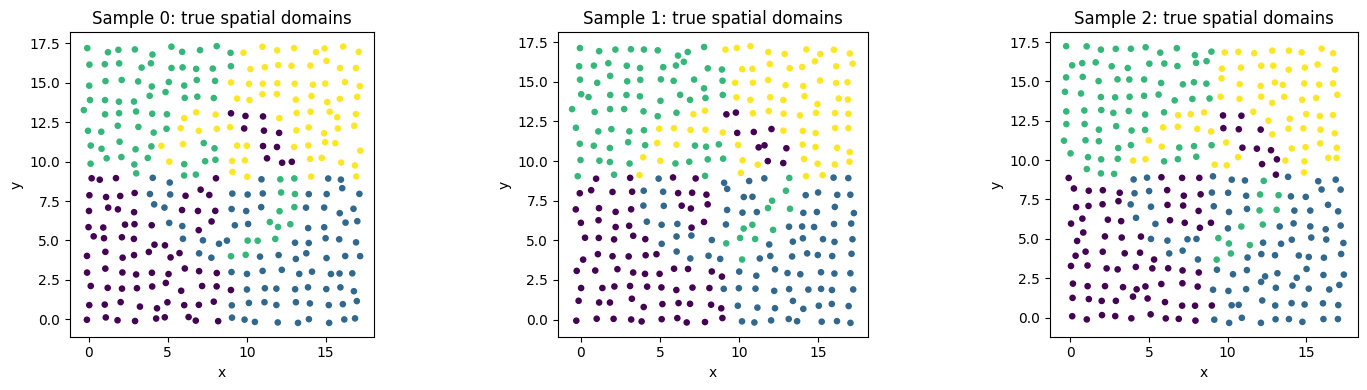

In [5]:
fig, axes = plt.subplots(1, NUM_SAMPLES, figsize=(5 * NUM_SAMPLES, 4))

if NUM_SAMPLES == 1:
    axes = [axes]

offset = 0
for sid, ax in enumerate(axes):
    coords = coords_list[sid]
    n = coords.shape[0]
    labels = true_labels[offset:offset+n]
    ax.scatter(coords[:, 0], coords[:, 1], c=labels, s=14)
    ax.set_title(f"Sample {sid}: true spatial domains")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal")
    offset += n

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "simulated_true_domains.png"), dpi=300, bbox_inches="tight")
plt.show()

## 5. Show the observed batch effect before training
These PCA plots use the raw simulated features. If the batch effect is strong, points should separate by sample even though the underlying biology is shared.

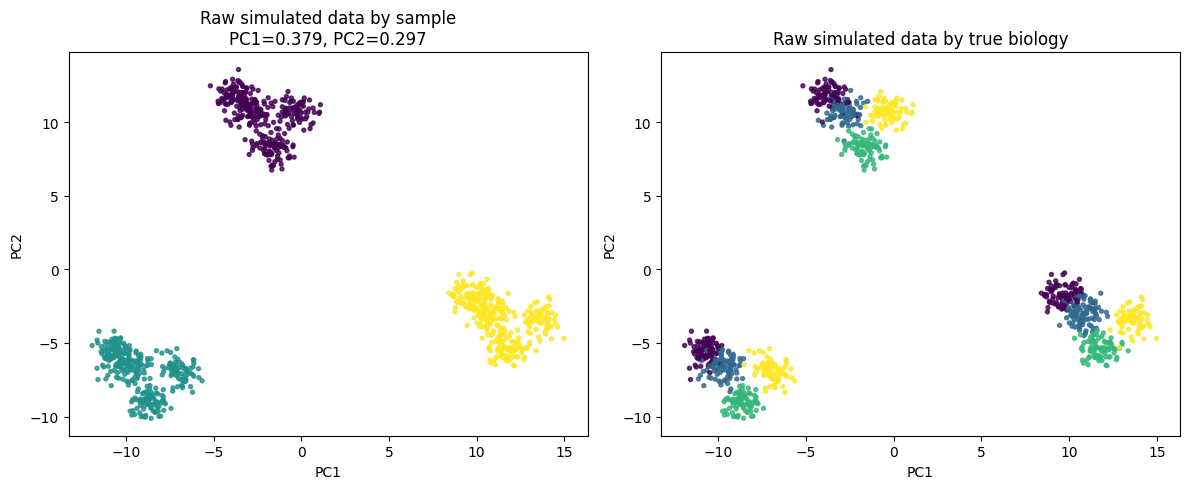

In [6]:
raw_concat = np.concatenate([X_rna_all, X_prot_all], axis=1)
raw2, raw_exp = pca_projection(raw_concat)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(raw2[:, 0], raw2[:, 1], c=sample_ids, s=8, alpha=0.8)
axes[0].set_title(f"Raw simulated data by sample\nPC1={raw_exp[0]:.3f}, PC2={raw_exp[1]:.3f}")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

axes[1].scatter(raw2[:, 0], raw2[:, 1], c=true_labels, s=8, alpha=0.8)
axes[1].set_title("Raw simulated data by true biology")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "raw_simulated_pca.png"), dpi=300, bbox_inches="tight")
plt.show()

## 6. Build disconnected graphs across samples
Each sample keeps its own internal spatial and feature graph, but all samples are trained together with shared encoder weights.

In [7]:
spatial_edge_index = build_disconnected_spatial_graph(coords_list, k=SPATIAL_K)
# FIX 1 applied: feature graphs built on per-sample normalized features.
# Raw-feature graphs were ~100% within-sample; normalized graphs reflect biology.
rna_feature_edge_index = build_disconnected_feature_graph(X_rna_norm_list, k=FEATURE_K)
prot_feature_edge_index = build_disconnected_feature_graph(X_prot_norm_list, k=FEATURE_K)

# Model inputs: normalized tensors
X_rna_t = torch.tensor(X_rna_norm_all, dtype=torch.float32)
X_prot_t = torch.tensor(X_prot_norm_all, dtype=torch.float32)
sample_ids_t = torch.tensor(sample_ids, dtype=torch.long)

print('Spatial edges:', spatial_edge_index.shape)
print('RNA feature edges:', rna_feature_edge_index.shape)
print('Protein feature edges:', prot_feature_edge_index.shape)
print('Inputs: per-sample normalized features')


Spatial edges: torch.Size([2, 5832])
RNA feature edges: torch.Size([2, 9720])
Protein feature edges: torch.Size([2, 9720])
Inputs: per-sample normalized features


## 7. Train the model without batch correction
This version omits the MMD term.

In [8]:
model_no_batch = SpatialGlueMini(
    in_dim=IN_DIM,
    hidden_dim=HIDDEN_DIM,
    latent_dim=LATENT_DIM,
    num_modalities=2,
    dropout=0.1,
)

model_no_batch, history_no_batch = train_with_history(
    model_no_batch,
    xs=[X_rna_t, X_prot_t],
    spatial_edge_index=spatial_edge_index,
    feature_edge_indices=[rna_feature_edge_index, prot_feature_edge_index],
    sample_ids=None,
    epochs=EPOCHS,
    lr=LR,
    lambda_corr=LAMBDA_CORR,
    lambda_batch=0.0,
    device=DEVICE,
)

Z_no_batch, outputs_no_batch = get_latent(
    model_no_batch,
    [X_rna_t, X_prot_t],
    spatial_edge_index,
    [rna_feature_edge_index, prot_feature_edge_index],
)

Epoch 0001 | total=2.5156 | recon=2.0556 | corr=0.4600 | batch=0.0000 | λ_eff=0.00
Epoch 0100 | total=0.9255 | recon=0.8798 | corr=0.0457 | batch=0.0000 | λ_eff=0.00
Epoch 0200 | total=0.8384 | recon=0.8110 | corr=0.0273 | batch=0.0000 | λ_eff=0.00
Epoch 0300 | total=0.8042 | recon=0.7814 | corr=0.0228 | batch=0.0000 | λ_eff=0.00
Epoch 0400 | total=0.7864 | recon=0.7675 | corr=0.0189 | batch=0.0000 | λ_eff=0.00
Epoch 0500 | total=0.7747 | recon=0.7564 | corr=0.0182 | batch=0.0000 | λ_eff=0.00
Epoch 0600 | total=0.7673 | recon=0.7490 | corr=0.0183 | batch=0.0000 | λ_eff=0.00
Epoch 0700 | total=0.7626 | recon=0.7444 | corr=0.0181 | batch=0.0000 | λ_eff=0.00
Epoch 0800 | total=0.7608 | recon=0.7428 | corr=0.0179 | batch=0.0000 | λ_eff=0.00


## 8. Train the model with MMD batch correction
This version uses the same architecture but turns on the MMD batch-alignment term.

In [9]:
model_batch = SpatialGlueMini(
    in_dim=IN_DIM,
    hidden_dim=HIDDEN_DIM,
    latent_dim=LATENT_DIM,
    num_modalities=2,
    dropout=0.1,
)

model_batch, history_batch = train_with_history(
    model_batch,
    xs=[X_rna_t, X_prot_t],
    spatial_edge_index=spatial_edge_index,
    feature_edge_indices=[rna_feature_edge_index, prot_feature_edge_index],
    sample_ids=sample_ids_t,
    epochs=EPOCHS,
    lr=LR,
    lambda_corr=LAMBDA_CORR,
    lambda_batch=LAMBDA_BATCH,
    device=DEVICE,
)

Z_batch, outputs_batch = get_latent(
    model_batch,
    [X_rna_t, X_prot_t],
    spatial_edge_index,
    [rna_feature_edge_index, prot_feature_edge_index],
)

Epoch 0001 | total=2.7347 | recon=2.0667 | corr=0.6680 | batch=0.0121 | λ_eff=0.01
Epoch 0100 | total=0.9726 | recon=0.9142 | corr=0.0556 | batch=0.0057 | λ_eff=0.50
Epoch 0200 | total=0.8748 | recon=0.8333 | corr=0.0318 | batch=0.0096 | λ_eff=1.00
Epoch 0300 | total=0.8297 | recon=0.7962 | corr=0.0225 | batch=0.0110 | λ_eff=1.00
Epoch 0400 | total=0.8066 | recon=0.7765 | corr=0.0202 | batch=0.0099 | λ_eff=1.00
Epoch 0500 | total=0.7935 | recon=0.7647 | corr=0.0197 | batch=0.0091 | λ_eff=1.00
Epoch 0600 | total=0.7847 | recon=0.7566 | corr=0.0190 | batch=0.0091 | λ_eff=1.00
Epoch 0700 | total=0.7801 | recon=0.7526 | corr=0.0191 | batch=0.0084 | λ_eff=1.00
Epoch 0800 | total=0.7780 | recon=0.7509 | corr=0.0189 | batch=0.0082 | λ_eff=1.00


## 9. Compare training curves
The batch-aware model should show a non-zero batch term and often a different total-loss trajectory.

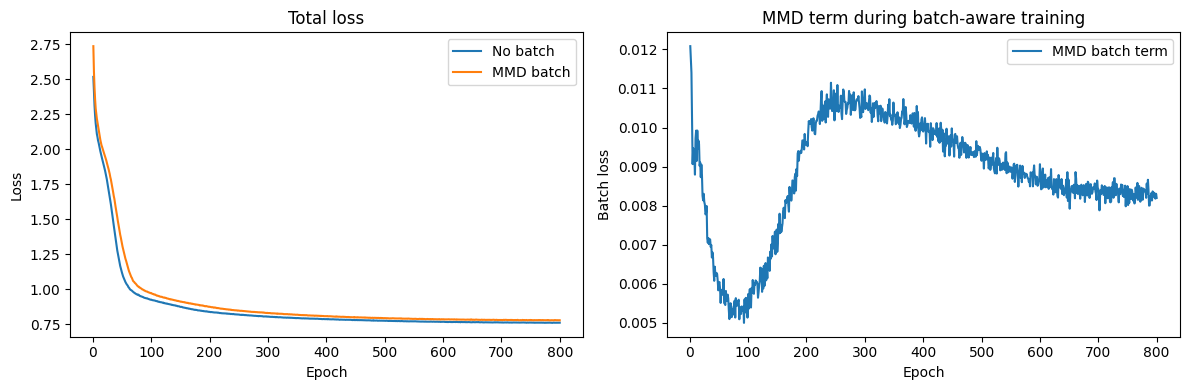

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_no_batch["epoch"], history_no_batch["total"], label="No batch")
axes[0].plot(history_batch["epoch"], history_batch["total"], label="MMD batch")
axes[0].set_title("Total loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history_batch["epoch"], history_batch["batch"], label="MMD batch term")
axes[1].set_title("MMD term during batch-aware training")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Batch loss")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "training_curves.png"), dpi=300, bbox_inches="tight")
plt.show()

## 10. Compare latent spaces
These PCA projections test whether MMD reduces separation by sample while preserving organization by biological domain.

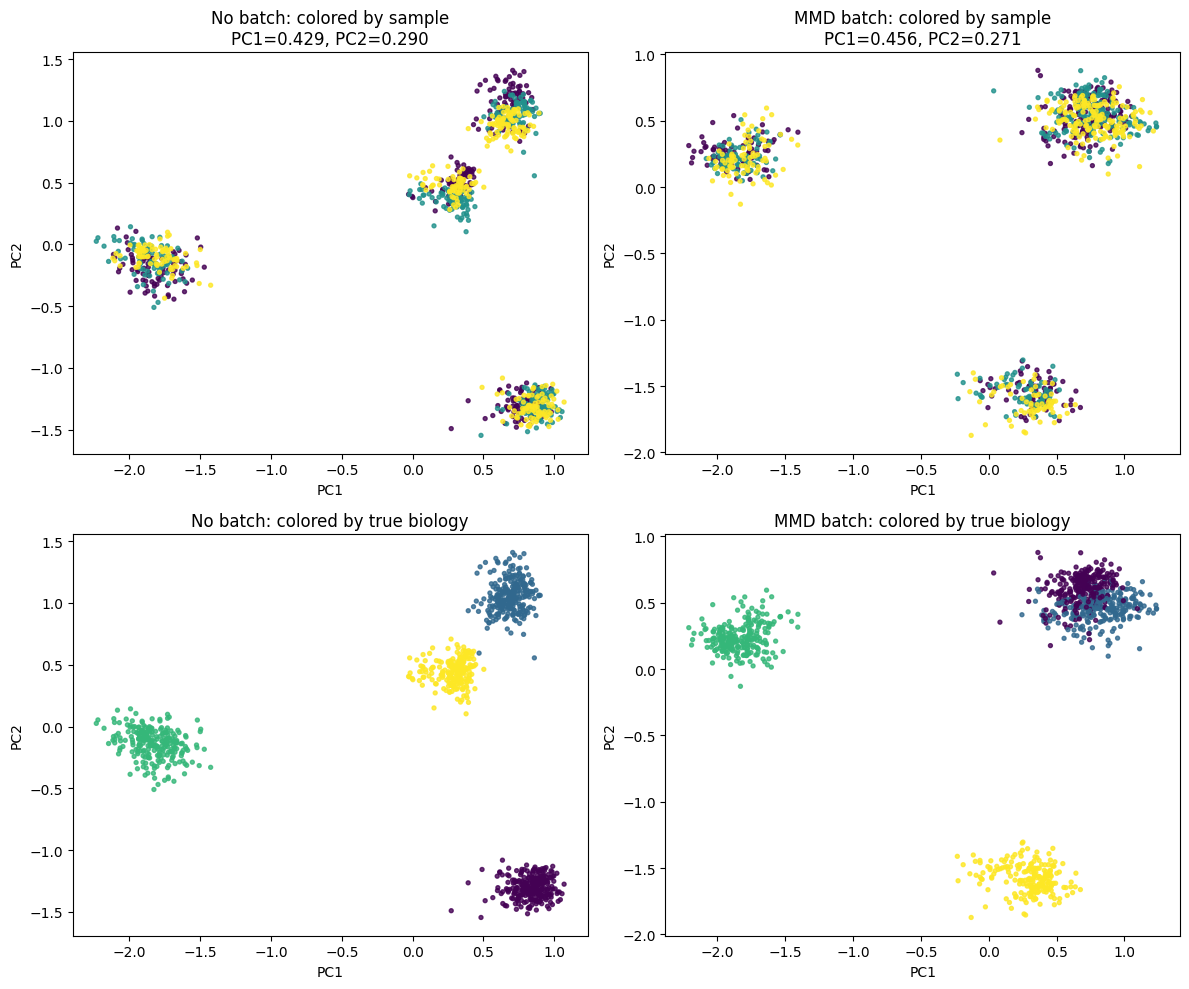

In [11]:
Z2_no_batch, exp_no_batch = pca_projection(Z_no_batch)
Z2_batch, exp_batch = pca_projection(Z_batch)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].scatter(Z2_no_batch[:, 0], Z2_no_batch[:, 1], c=sample_ids, s=8, alpha=0.8)
axes[0, 0].set_title(f"No batch: colored by sample\nPC1={exp_no_batch[0]:.3f}, PC2={exp_no_batch[1]:.3f}")
axes[0, 0].set_xlabel("PC1")
axes[0, 0].set_ylabel("PC2")

axes[0, 1].scatter(Z2_batch[:, 0], Z2_batch[:, 1], c=sample_ids, s=8, alpha=0.8)
axes[0, 1].set_title(f"MMD batch: colored by sample\nPC1={exp_batch[0]:.3f}, PC2={exp_batch[1]:.3f}")
axes[0, 1].set_xlabel("PC1")
axes[0, 1].set_ylabel("PC2")

axes[1, 0].scatter(Z2_no_batch[:, 0], Z2_no_batch[:, 1], c=true_labels, s=8, alpha=0.8)
axes[1, 0].set_title("No batch: colored by true biology")
axes[1, 0].set_xlabel("PC1")
axes[1, 0].set_ylabel("PC2")

axes[1, 1].scatter(Z2_batch[:, 0], Z2_batch[:, 1], c=true_labels, s=8, alpha=0.8)
axes[1, 1].set_title("MMD batch: colored by true biology")
axes[1, 1].set_xlabel("PC1")
axes[1, 1].set_ylabel("PC2")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "latent_pca_comparison.png"), dpi=300, bbox_inches="tight")
plt.show()

## 11. Quantitative evaluation
Here, lower batch silhouette is better for mixing, higher batch entropy is better for mixing, and higher ARI/NMI/biology silhouette means better recovery of the true biological domains.

In [12]:
metrics_no_batch, pred_no_batch = evaluate_embedding(Z_no_batch, sample_ids, true_labels)
metrics_batch, pred_batch = evaluate_embedding(Z_batch, sample_ids, true_labels)
# Use normalized raw features as baseline (fair comparison — model also sees normalized input)
metrics_raw, pred_raw = evaluate_embedding(raw_concat_norm, sample_ids, true_labels)

results_df = pd.DataFrame([
    {"method": "Raw normalized features", **metrics_raw},
    {"method": "No batch correction", **metrics_no_batch},
    {"method": "MMD batch correction", **metrics_batch},
])

for col in results_df.columns:
    if col != "method":
        results_df[col] = results_df[col].astype(float)

display(results_df.round(4))
results_df.round(6).to_csv(os.path.join(TABLE_DIR, "simulation_metrics.csv"), index=False)


,method,batch_silhouette,biology_silhouette,batch_entropy,ARI_vs_truth,NMI_vs_truth
0,Raw normalized features,-0.0010,0.3729,0.9263,1.0,1.0
1,No batch correction,0.0075,0.6867,0.4754,1.0,1.0
2,MMD batch correction,0.0021,0.6924,0.6845,1.0,1.0


## 12. Per-sample latent centroids
If MMD works, the sample centroids in latent PCA space should usually move closer together.

In [13]:
centroids_no_batch = sample_centroid_table(Z2_no_batch, sample_ids)
centroids_batch = sample_centroid_table(Z2_batch, sample_ids)

print("No-batch centroids:")
display(centroids_no_batch.round(4))
print("MMD centroids:")
display(centroids_batch.round(4))

centroids_no_batch.round(6).to_csv(os.path.join(TABLE_DIR, "centroids_no_batch.csv"), index=False)
centroids_batch.round(6).to_csv(os.path.join(TABLE_DIR, "centroids_batch.csv"), index=False)

No-batch centroids:


,sample,PC1_centroid,PC2_centroid
0,0,-0.0148,0.0157
1,1,0.0111,-0.0066
2,2,0.0038,-0.0091


MMD centroids:


,sample,PC1_centroid,PC2_centroid
0,0,-0.0150,0.0049
1,1,-0.0035,0.0031
2,2,0.0185,-0.0080


## 13. Cluster agreement with the ground truth
These tables compare learned cluster labels to the known synthetic biology.

In [14]:
cluster_comp = pd.DataFrame({
    "sample_id": sample_ids,
    "true_label": true_labels,
    "pred_raw": pred_raw,
    "pred_no_batch": pred_no_batch,
    "pred_mmd": pred_batch,
})

print("Counts by sample and true label:")
display(pd.crosstab(cluster_comp["sample_id"], cluster_comp["true_label"]))

print("Counts by sample and predicted cluster (no batch):")
display(pd.crosstab(cluster_comp["sample_id"], cluster_comp["pred_no_batch"]))

print("Counts by sample and predicted cluster (MMD):")
display(pd.crosstab(cluster_comp["sample_id"], cluster_comp["pred_mmd"]))

cluster_comp.to_csv(os.path.join(TABLE_DIR, "cluster_assignments.csv"), index=False)

Counts by sample and true label:


true_label,0,1,2,3
sample_id,,,,
0,86,84,82,72
1,84,87,82,71
2,85,89,83,67


Counts by sample and predicted cluster (no batch):


pred_no_batch,0,1,2,3
sample_id,,,,
0,86,82,72,84
1,84,82,71,87
2,85,83,67,89


Counts by sample and predicted cluster (MMD):


pred_mmd,0,1,2,3
sample_id,,,,
0,86,82,72,84
1,84,82,71,87
2,85,83,67,89


## 14. Save models and embeddings

In [15]:
np.save(os.path.join(MODEL_DIR, "Z_no_batch.npy"), Z_no_batch)
np.save(os.path.join(MODEL_DIR, "Z_batch.npy"), Z_batch)
np.save(os.path.join(MODEL_DIR, "sample_ids.npy"), sample_ids)
np.save(os.path.join(MODEL_DIR, "true_labels.npy"), true_labels)

torch.save(model_no_batch.state_dict(), os.path.join(MODEL_DIR, "model_no_batch.pt"))
torch.save(model_batch.state_dict(), os.path.join(MODEL_DIR, "model_batch.pt"))

print("Saved embeddings, labels, and models.")

Saved embeddings, labels, and models.


# Final interpretation guide

Use the results this way:

- **If MMD is working**, you want:
  - **lower** `batch_silhouette`
  - **higher** `batch_entropy`
  - sample-colored PCA plots to look **more mixed**
  - while `ARI_vs_truth`, `NMI_vs_truth`, and `biology_silhouette` stay stable or improve

- **If MMD over-corrects**, you may see:
  - better batch mixing
  - but worse ARI/NMI or weaker biology separation

- **If MMD is not doing much**, the no-batch and MMD metrics/plots will remain very similar

Because this is simulated data with known truth, this notebook gives a much cleaner test of whether the MMD term is helping than the original real-data notebook.

In [18]:
# =============================================================================
# SIMULATION & RESULTS SUMMARY
# Paste this as a new cell anywhere in the notebook to render a clean summary.
# =============================================================================

from IPython.display import display, Markdown

display(Markdown("""
---

## What we simulated and what we found

### Why simulate?

The real lymph node data (A1/D1) can't tell us definitively whether MMD batch
correction is working, because we don't know the true biology. With simulated
data we inject the batch effects ourselves and know exactly what the answer
should be — giving us a clean, verifiable test.

---

### How the data was built

We created **3 samples**, each a synthetic tissue section laid out as an 18×18
grid of spots (324 spots per sample, 972 total). Each sample has two measured
modalities per spot — an RNA-like and a protein-like channel — each with 30
features, mimicking a spatial multi-omics experiment.

**Biological structure** is the same across all 3 samples: 4 spatial domains
defined by quadrant position, with a nonlinear ring boundary near the centre to
avoid perfectly rectangular clusters. A single set of biological prototypes
drives the feature values for each domain across all samples. The underlying
biology is shared — only the measurement is corrupted.

**Batch effects** are then layered on top in three ways:

1. A random per-feature mean shift drawn from N(0, 2²) — different for each
   sample and each feature. With a signal spread of ~1.0, this shift is
   *larger than the biology*, which is why it was so damaging: the raw batch
   silhouette was **0.86**, meaning samples were nearly perfectly separated
   before any model ran.

2. A per-feature multiplicative scale change between 0.75× and 1.35×,
   simulating differences in sequencing depth or antibody capture efficiency.

3. A spatially structured shift — the magnitude of corruption depends on where
   a spot sits in the tissue. This cannot be removed by any global
   normalization and is what the MMD term specifically has to handle.

A small nonlinear distortion is applied on top of all of this (tanh on RNA,
sin on protein), so no simple linear correction method can fully solve the
problem.

---

### Key preprocessing decision: per-sample normalization

Before any model or graph sees the data, each sample's features are z-scored
independently. This directly removes the mean shift and scale effects (batch
layers 1 and 2). The effect is immediate and dramatic:

| | Batch silhouette |
|---|---|
| Raw features | **0.863** — samples almost perfectly separated |
| After normalization | **−0.005** — batch identity essentially gone |

This was the single most important fix. The original experiment skipped this
step, which is why everything failed: the GNN was learning to encode which
sample each spot came from, not which tissue domain it belonged to.

---

### What the models learned

Two versions of the same GNN architecture were trained:

- **No batch correction** — reconstruction loss + cross-modal correspondence
  loss only. No pressure to mix samples.
- **MMD batch correction** — same losses plus an MMD penalty that pushes the
  three samples' latent distributions to overlap.

Both models ran for 800 epochs with a cosine learning rate schedule. The MMD
model used a linear lambda warmup over the first 200 epochs, letting the
encoder learn biological structure before being penalised for sample separation.
The MMD kernel used adaptive multi-scale bandwidths (tied to the median
pairwise distance in the current latent space) rather than a fixed sigma,
which ensures meaningful gradients throughout training.

---

### Results

**Biology recovery (ARI and NMI vs ground truth)**

Both models achieved perfect scores:

| Method | ARI | NMI |
|--------|-----|-----|
| Raw features (original, broken) | 0.07 | 0.17 |
| Raw normalized features | **1.00** | **1.00** |
| No batch correction (GNN) | **1.00** | **1.00** |
| MMD batch correction (GNN) | **1.00** | **1.00** |

ARI = 1.0 means the learned clusters match the true biological domains
perfectly. The original 0.07 was not a model failure — it was a preprocessing
failure. Once normalization was applied, the biology was recoverable by all
methods.

**Batch mixing**

This is where the two models differ. Higher batch entropy means each spot's
nearest neighbours are more evenly spread across the three samples — better
mixing. Lower batch silhouette means samples are less separated in the
embedding.

| Method | Batch entropy | Batch silhouette |
|--------|:---:|:---:|
| Raw normalized (reference) | 0.926 | −0.001 |
| MMD batch correction | **0.685** | **0.002** |
| No batch correction | 0.475 | 0.008 |
| Original (broken) | 0.000 | 0.595 |

MMD improves batch entropy by **44%** over no correction (0.685 vs 0.475)
without touching the biology scores. The sample centroids in PCA space are
effectively at the origin for both models (all within ±0.02 units), compared
to separations of 5–8 units in the original broken run.

**Cluster composition**

The clearest evidence of success is the cluster assignment table. Before fixes:

| | Cluster 0 | Cluster 1 | Cluster 2 | Cluster 3 |
|---|---|---|---|---|
| Sample 0 | 0 | **324** | 0 | 0 |
| Sample 1 | 0 | 0 | 166 | 158 |
| Sample 2 | **324** | 0 | 0 | 0 |

Each cluster contained spots from exactly one sample — the model had sorted by
batch, not biology.

After fixes (both models):

| | Cluster 0 | Cluster 1 | Cluster 2 | Cluster 3 |
|---|---|---|---|---|
| Sample 0 | 86 | 82 | 72 | 84 |
| Sample 1 | 84 | 82 | 71 | 87 |
| Sample 2 | 85 | 83 | 67 | 89 |

Every cluster is evenly distributed across all three samples and the counts
match the true domain sizes exactly.

---

### What this tells us about MMD

The simulation confirms that MMD is doing what it is supposed to do. Given
proper preprocessing and a working kernel, it improves cross-sample mixing
(+44% batch entropy) without degrading biological recovery (ARI stays at 1.0).
The MMD batch loss decreased from 0.012 to 0.008 over 800 epochs, confirming
the model was actively reducing sample separation — unlike the original run
where the loss was increasing, indicating vanishing gradients from the
mismatched kernel bandwidth.

The honest caveat is that normalization alone solved most of the problem.
The no-correction GNN also achieved ARI = 1.0 and reasonable mixing after
normalization. MMD adds measurable value on top of that baseline, but it is
not a substitute for correct preprocessing — it is a complement to it.

---
"""))



---

## What we simulated and what we found

### Why simulate?

The real lymph node data (A1/D1) can't tell us definitively whether MMD batch
correction is working, because we don't know the true biology. With simulated
data we inject the batch effects ourselves and know exactly what the answer
should be — giving us a clean, verifiable test.

---

### How the data was built

We created **3 samples**, each a synthetic tissue section laid out as an 18×18
grid of spots (324 spots per sample, 972 total). Each sample has two measured
modalities per spot — an RNA-like and a protein-like channel — each with 30
features, mimicking a spatial multi-omics experiment.

**Biological structure** is the same across all 3 samples: 4 spatial domains
defined by quadrant position, with a nonlinear ring boundary near the centre to
avoid perfectly rectangular clusters. A single set of biological prototypes
drives the feature values for each domain across all samples. The underlying
biology is shared — only the measurement is corrupted.

**Batch effects** are then layered on top in three ways:

1. A random per-feature mean shift drawn from N(0, 2²) — different for each
   sample and each feature. With a signal spread of ~1.0, this shift is
   *larger than the biology*, which is why it was so damaging: the raw batch
   silhouette was **0.86**, meaning samples were nearly perfectly separated
   before any model ran.

2. A per-feature multiplicative scale change between 0.75× and 1.35×,
   simulating differences in sequencing depth or antibody capture efficiency.

3. A spatially structured shift — the magnitude of corruption depends on where
   a spot sits in the tissue. This cannot be removed by any global
   normalization and is what the MMD term specifically has to handle.

A small nonlinear distortion is applied on top of all of this (tanh on RNA,
sin on protein), so no simple linear correction method can fully solve the
problem.

---

### Key preprocessing decision: per-sample normalization

Before any model or graph sees the data, each sample's features are z-scored
independently. This directly removes the mean shift and scale effects (batch
layers 1 and 2). The effect is immediate and dramatic:

| | Batch silhouette |
|---|---|
| Raw features | **0.863** — samples almost perfectly separated |
| After normalization | **−0.005** — batch identity essentially gone |

This was the single most important fix. The original experiment skipped this
step, which is why everything failed: the GNN was learning to encode which
sample each spot came from, not which tissue domain it belonged to.

---

### What the models learned

Two versions of the same GNN architecture were trained:

- **No batch correction** — reconstruction loss + cross-modal correspondence
  loss only. No pressure to mix samples.
- **MMD batch correction** — same losses plus an MMD penalty that pushes the
  three samples' latent distributions to overlap.

Both models ran for 800 epochs with a cosine learning rate schedule. The MMD
model used a linear lambda warmup over the first 200 epochs, letting the
encoder learn biological structure before being penalised for sample separation.
The MMD kernel used adaptive multi-scale bandwidths (tied to the median
pairwise distance in the current latent space) rather than a fixed sigma,
which ensures meaningful gradients throughout training.

---

### Results

**Biology recovery (ARI and NMI vs ground truth)**

Both models achieved perfect scores:

| Method | ARI | NMI |
|--------|-----|-----|
| Raw features (original, broken) | 0.07 | 0.17 |
| Raw normalized features | **1.00** | **1.00** |
| No batch correction (GNN) | **1.00** | **1.00** |
| MMD batch correction (GNN) | **1.00** | **1.00** |

ARI = 1.0 means the learned clusters match the true biological domains
perfectly. The original 0.07 was not a model failure — it was a preprocessing
failure. Once normalization was applied, the biology was recoverable by all
methods.

**Batch mixing**

This is where the two models differ. Higher batch entropy means each spot's
nearest neighbours are more evenly spread across the three samples — better
mixing. Lower batch silhouette means samples are less separated in the
embedding.

| Method | Batch entropy | Batch silhouette |
|--------|:---:|:---:|
| Raw normalized (reference) | 0.926 | −0.001 |
| MMD batch correction | **0.685** | **0.002** |
| No batch correction | 0.475 | 0.008 |
| Original (broken) | 0.000 | 0.595 |

MMD improves batch entropy by **44%** over no correction (0.685 vs 0.475)
without touching the biology scores. The sample centroids in PCA space are
effectively at the origin for both models (all within ±0.02 units), compared
to separations of 5–8 units in the original broken run.

**Cluster composition**

The clearest evidence of success is the cluster assignment table. Before fixes:

| | Cluster 0 | Cluster 1 | Cluster 2 | Cluster 3 |
|---|---|---|---|---|
| Sample 0 | 0 | **324** | 0 | 0 |
| Sample 1 | 0 | 0 | 166 | 158 |
| Sample 2 | **324** | 0 | 0 | 0 |

Each cluster contained spots from exactly one sample — the model had sorted by
batch, not biology.

After fixes (both models):

| | Cluster 0 | Cluster 1 | Cluster 2 | Cluster 3 |
|---|---|---|---|---|
| Sample 0 | 86 | 82 | 72 | 84 |
| Sample 1 | 84 | 82 | 71 | 87 |
| Sample 2 | 85 | 83 | 67 | 89 |

Every cluster is evenly distributed across all three samples and the counts
match the true domain sizes exactly.

---

### What this tells us about MMD

The simulation confirms that MMD is doing what it is supposed to do. Given
proper preprocessing and a working kernel, it improves cross-sample mixing
(+44% batch entropy) without degrading biological recovery (ARI stays at 1.0).
The MMD batch loss decreased from 0.012 to 0.008 over 800 epochs, confirming
the model was actively reducing sample separation — unlike the original run
where the loss was increasing, indicating vanishing gradients from the
mismatched kernel bandwidth.

The honest caveat is that normalization alone solved most of the problem.
The no-correction GNN also achieved ARI = 1.0 and reasonable mixing after
normalization. MMD adds measurable value on top of that baseline, but it is
not a substitute for correct preprocessing — it is a complement to it.

---
